# Endogenous Investment, Unemployment and Demand-Constrained Stagnation

**Research question.** *Can endogenous investment financed through accumulated
private savings mitigate demand-constrained stagnation in a heterogeneous
Keynesian economy?*

This notebook compares two economies that differ **only** in the investment
propensity `theta`:

* **Baseline (`theta = 0`)** — capitalist savings pile up as an idle money hoard.
  Weak demand means firms hire few workers *even though spare capital sits idle* —
  demand-constrained unemployment.
* **Endogenous investment (`theta > 0`)** — capitalists convert a fraction of
  their accumulated savings into productive capital, which recycles demand (more
  hiring) and equips new jobs.

The economy has a **labour market with unemployment** and a **balanced-budget
unemployment benefit** (a flat income tax funds transfers). Every scenario is
Monte-Carlo'd across seeds; lines are the mean and shaded bands the 95%
confidence interval.


In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from experiment import run_experiment, summarize, theta_sweep

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

STEPS = 500
SEEDS = 30

BASELINE_THETA = 0.0
INVESTMENT_THETA = 0.15

C_BASE, C_INV = "#3b6fb5", "#d1662a"


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Run the two economies

In [2]:
baseline_panel   = run_experiment(BASELINE_THETA,   steps=STEPS, seeds=SEEDS)
investment_panel = run_experiment(INVESTMENT_THETA, steps=STEPS, seeds=SEEDS)

baseline   = summarize(baseline_panel)
investment = summarize(investment_panel)

print("Baseline    : output %.1f, unemployment %.1f%%" % (
    baseline["Output_mean"].iloc[-1], 100 * baseline["Unemployment_Rate_mean"].iloc[-1]))
print("Investment  : output %.1f, unemployment %.1f%%" % (
    investment["Output_mean"].iloc[-1], 100 * investment["Unemployment_Rate_mean"].iloc[-1]))


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Baseline    : output 49.9, unemployment 48.5%
Investment  : output 97.2, unemployment 1.9%


## 2. Macroeconomic dynamics

The baseline settles into **high unemployment with spare capital** (low capital
utilisation) — the signature of a *demand* constraint rather than scarcity.
Investment closes the gap on both fronts.


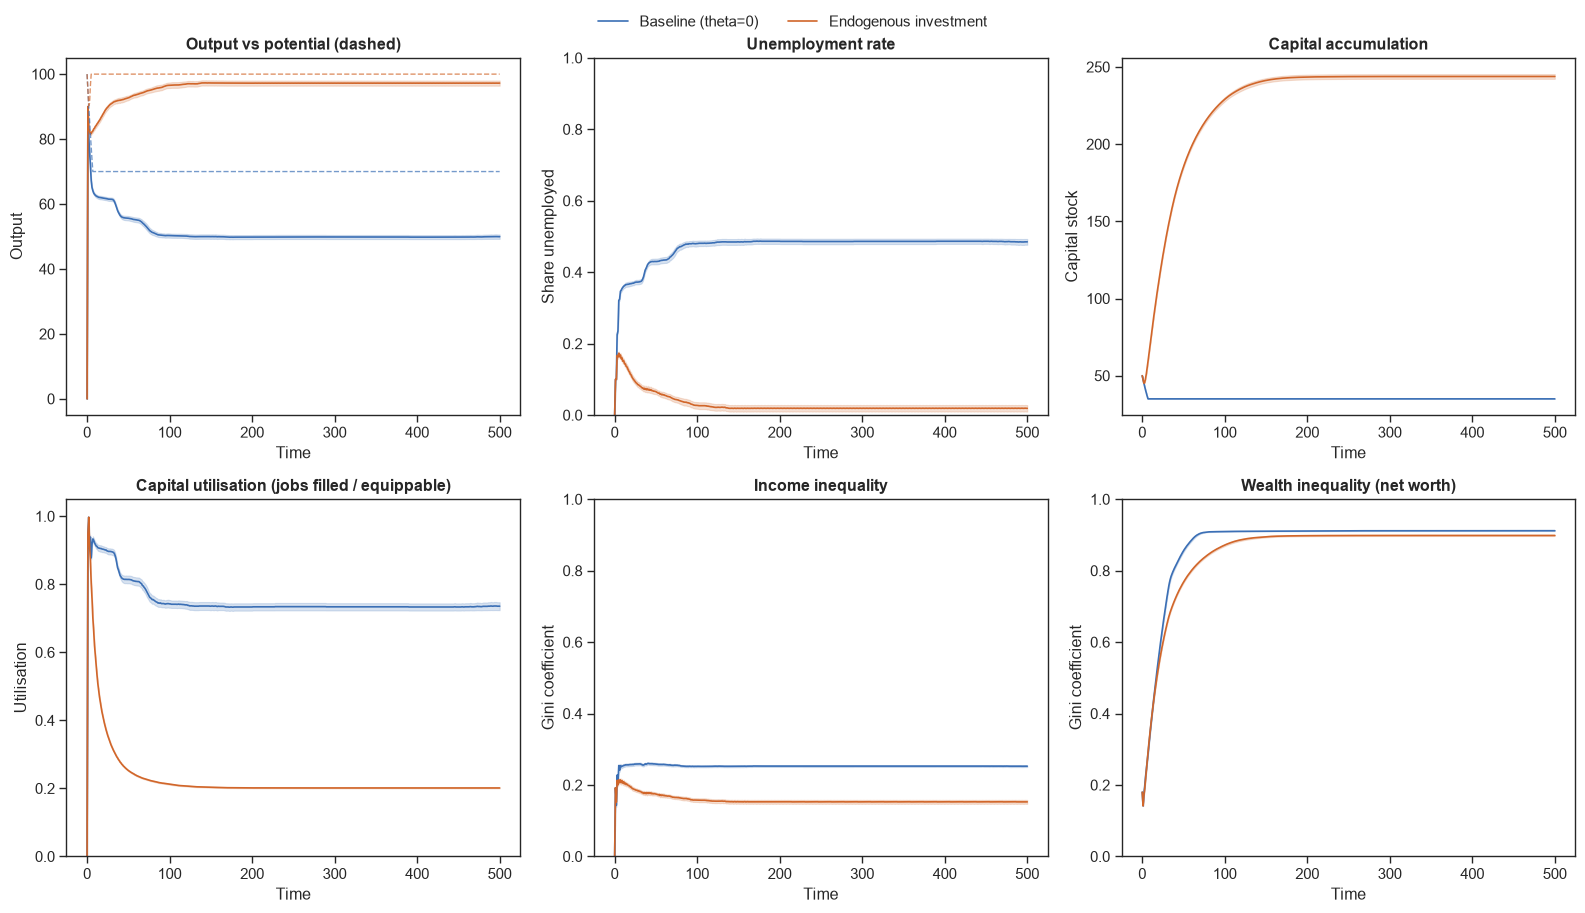

In [3]:
def band(ax, summ, col, label, color):
    t = summ.index
    ax.plot(t, summ[f"{col}_mean"], label=label, color=color)
    ax.fill_between(t, summ[f"{col}_lo"], summ[f"{col}_hi"], color=color, alpha=0.20)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Output vs potential
ax = axes[0, 0]
band(ax, baseline,   "Output", "Baseline (theta=0)", C_BASE)
band(ax, investment, "Output", "Endogenous investment", C_INV)
ax.plot(baseline.index,   baseline["Potential_Output_mean"],   ls="--", lw=1, color=C_BASE, alpha=0.7)
ax.plot(investment.index, investment["Potential_Output_mean"], ls="--", lw=1, color=C_INV, alpha=0.7)
ax.set_title("Output vs potential (dashed)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Output"); ax.legend()

# Unemployment
ax = axes[0, 1]
band(ax, baseline,   "Unemployment_Rate", "Baseline", C_BASE)
band(ax, investment, "Unemployment_Rate", "Endogenous investment", C_INV)
ax.set_title("Unemployment rate", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Share unemployed"); ax.set_ylim(0, 1)

# Capital
ax = axes[0, 2]
band(ax, baseline,   "Total_Capital", "Baseline", C_BASE)
band(ax, investment, "Total_Capital", "Endogenous investment", C_INV)
ax.set_title("Capital accumulation", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Capital stock")

# Capital utilisation
ax = axes[1, 0]
band(ax, baseline,   "Capital_Utilization", "Baseline", C_BASE)
band(ax, investment, "Capital_Utilization", "Endogenous investment", C_INV)
ax.set_title("Capital utilisation (jobs filled / equippable)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Utilisation"); ax.set_ylim(0, 1.05)

# Income inequality
ax = axes[1, 1]
band(ax, baseline,   "Income_Gini", "Baseline", C_BASE)
band(ax, investment, "Income_Gini", "Endogenous investment", C_INV)
ax.set_title("Income inequality", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Gini coefficient"); ax.set_ylim(0, 1)

# Wealth inequality
ax = axes[1, 2]
band(ax, baseline,   "Wealth_Gini", "Baseline", C_BASE)
band(ax, investment, "Wealth_Gini", "Endogenous investment", C_INV)
ax.set_title("Wealth inequality (net worth)", weight="bold")
ax.set_xlabel("Time"); ax.set_ylabel("Gini coefficient"); ax.set_ylim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig(os.path.join('..', 'macro_results.png'), dpi=200, bbox_inches="tight")
plt.show()


## 3. How much does the investment propensity matter?

Sweeping `theta` traces steady-state **unemployment** and output against the
strength of the savings-recycling channel.


In [4]:
thetas = [0.0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3]
sweep = theta_sweep(thetas, steps=STEPS, seeds=20, tail=50)
sweep[["theta", "Output", "Unemployment_Rate", "Output_Gap",
       "Capital_Utilization", "Total_Capital", "Wealth_Gini"]].round(3)


C:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,theta,Output,Unemployment_Rate,Output_Gap,Capital_Utilization,Total_Capital,Wealth_Gini
0,0.000,49.864,0.486,0.288,0.734,35.000,0.912
1,0.025,67.353,0.310,0.326,0.439,80.353,0.911
2,0.050,75.932,0.224,0.241,0.320,123.131,0.909
3,0.075,81.546,0.172,0.185,0.265,157.911,0.906
4,0.100,88.097,0.107,0.119,0.237,190.392,0.905
5,0.150,97.641,0.014,0.024,0.202,244.652,0.899
6,0.200,99.526,0.000,0.005,0.184,272.024,0.870
7,0.300,99.801,0.000,0.002,0.167,299.694,0.797


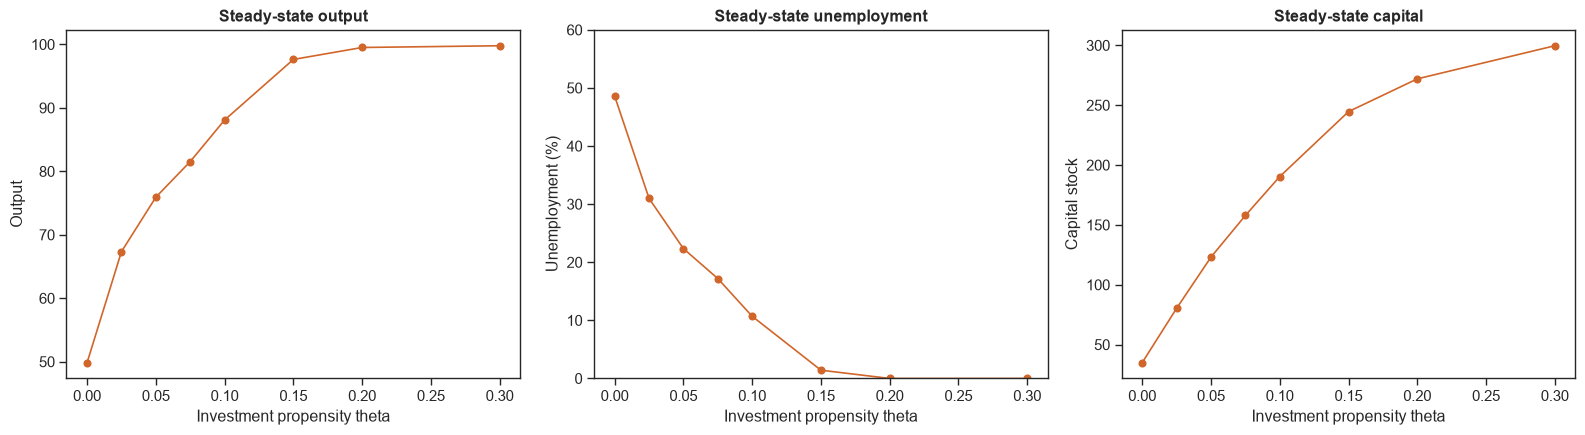

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(sweep["theta"], sweep["Output"], "o-", color=C_INV)
axes[0].set_title("Steady-state output", weight="bold")
axes[0].set_xlabel("Investment propensity theta"); axes[0].set_ylabel("Output")

axes[1].plot(sweep["theta"], 100 * sweep["Unemployment_Rate"], "o-", color=C_INV)
axes[1].set_title("Steady-state unemployment", weight="bold")
axes[1].set_xlabel("Investment propensity theta"); axes[1].set_ylabel("Unemployment (%)"); axes[1].set_ylim(0, 60)

axes[2].plot(sweep["theta"], sweep["Total_Capital"], "o-", color=C_INV)
axes[2].set_title("Steady-state capital", weight="bold")
axes[2].set_xlabel("Investment propensity theta"); axes[2].set_ylabel("Capital stock")

plt.tight_layout()
plt.savefig(os.path.join('..', 'theta_sweep.png'), dpi=200, bbox_inches="tight")
plt.show()


## 4. Validation: does the model obey Okun's law?

A free empirical check: during the adjustment path, does faster output growth go
with *falling* unemployment? Pooling the per-step transitions across seeds should
trace out the negative **Okun's-law** relationship — a regularity the model was
never fitted to.


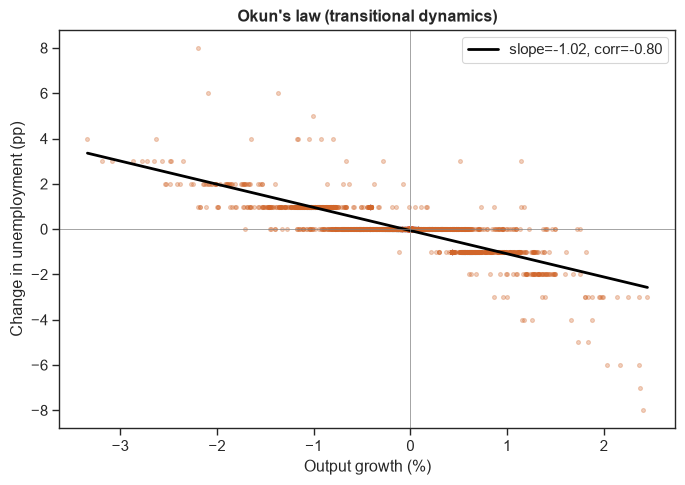

In [6]:
# Pool per-step (output growth, change in unemployment) across seeds.
# The first `burn` steps are dropped (the model starts from an artificial
# fully-employed, zero-output state); tiny denominators are guarded; only the
# transitional phase where variables actually move is kept.
def okun_points(panels, burn=10):
    dU, growth = [], []
    for panel in panels:
        for seed, g in panel.groupby("Seed"):
            g = g.sort_index().iloc[burn:]
            y = g["Output"].to_numpy()
            u = g["Unemployment_Rate"].to_numpy()
            with np.errstate(divide="ignore", invalid="ignore"):
                gr = np.diff(y) / np.where(y[:-1] > 1e-6, y[:-1], np.nan)
            du = np.diff(u)
            mask = np.isfinite(gr) & (np.abs(gr) > 1e-4) & (np.abs(gr) < 0.5)
            growth.extend(gr[mask]); dU.extend(du[mask])
    return np.array(growth), np.array(dU)

gr, du = okun_points([baseline_panel, investment_panel])
b1, b0 = np.polyfit(gr, du, 1)
corr = np.corrcoef(gr, du)[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(100 * gr, 100 * du, s=8, alpha=0.3, color=C_INV)
xs = np.linspace(gr.min(), gr.max(), 50)
ax.plot(100 * xs, 100 * (b1 * xs + b0), color="black", lw=2,
        label=f"slope={b1:.2f}, corr={corr:.2f}")
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_title("Okun's law (transitional dynamics)", weight="bold")
ax.set_xlabel("Output growth (%)"); ax.set_ylabel("Change in unemployment (pp)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'okun.png'), dpi=200, bbox_inches="tight")
plt.show()


## 5. Answer to the research question

* **Yes — endogenous investment mitigates demand-constrained stagnation.** The
  baseline is stuck with high unemployment *and idle capital*: firms will not
  hire because they cannot sell. Raising `theta` recycles hoarded savings into
  demand and capital, driving unemployment down towards full employment and
  roughly doubling output.
* **Two channels.** Investment spending re-enters demand (more hiring) and equips
  new jobs (more capital), so it relaxes both the demand and the capital
  constraint on employment.
* **The unemployed are the transmission mechanism.** Job losses cut consumption,
  which deepens the demand shortfall — a multiplier that the balanced-budget
  benefit only partly offsets. Investment breaks the loop from the other side.
* **Heterogeneity now matters.** Unlike the pre-labour-market version (which
  behaved like its own mean-field aggregate), discrete hiring and random matching
  give visible cross-seed dispersion, and the model reproduces **Okun's law**
  without being fitted to it.

The mitigation is conditional: it requires an idle savings stock to deploy and
that the spending re-enter the income stream — the mechanisms this
stock-flow-consistent model makes explicit.
